## uwin - Pipeline

In [1]:
import os
os.environ["UWIN_SITE"] = "013054"

from uwinControl import config
SITE = config.get_site()
print(SITE["station_code"])

013054


### เรียกใช้ฟังก์ชันต่างๆ จากโฟลเดอร์ src

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from uwinControl import config, data_io, energy, features, finance, models, qc, reference

# ตั้งค่ากราฟ
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# อ่านค่าไซต์งานจาก env UWIN_SITE
SITE = config.get_site() # อ่านจาก UWIN_SITE ใน docker-compose
print('ไซต์งาน:', SITE['station_code'])
print('เสาวัดลม:', SITE['mast_height_m'], 'ม.')
print('จังหวัด:', SITE['province'])

# ค่าที่ต่างกันไปในแต่ละไซต์ ดึงจาก config ทั้งหมด ไม่ต้องมาแก้ในโน้ตบุ๊ก
TOP = config.top_sensor() # เซนเซอร์ยอดเสา
TARGET = f"WS{SITE['mast_height_m']}" # คอลัมน์ลมยอดเสาหลังรวมคู่แก้เงาเสาแล้ว
BASE = SITE['base_sensor'] # เซนเซอร์ฐานของ Power Law
BASE_H = SITE['sensor_heights'][BASE]
HUB_HEIGHT_M = SITE['hub_height_m']
FEATURES = features.feature_columns()

problems = config.validate_site()
print('ตรวจ config:', 'ผ่าน' if not problems else problems)
print('เซนเซอร์ยอดเสา:', TOP)
print('Power Law:', BASE, f'({BASE_H} ม.)')
print('hub height:', HUB_HEIGHT_M, 'ม.')

ไซต์งาน: 013054
เสาวัดลม: 160 ม.
จังหวัด: ยโสธร
ตรวจ config: ผ่าน
เซนเซอร์ยอดเสา: WS160_N
Power Law: WS100 (100 ม.)
hub height: 150 ม.


### 1.แสดงรายละเอียดข้อมูลไซต์

In [3]:
# TODO ERA5 จาก CDS
era5_data = reference.load_era5()
# TODO ข้อมูลจากเสาจริง (เป็นข้อมูลแบบ long format ใช้ฟังก์ชัน load_raw_data เพื้อแปลงเป็น pivot)
raw_data = data_io.load_raw_data('wind_raws_202608181213.csv')

# ข้อมูลสรุปภาพรวม
def datasite_describe(raw_data, site):
    num_total = len(raw_data)
    days = (raw_data.index[-1] - raw_data.index[0]).days
    rows_per_day =  num_total / days
    expected = site["records_per_day"]
    interval_min = round(24 * 60 / rows_per_day) # ระยะห่างต่อแถวของข้อมูล

    print(f"ข้อมูลภาพรวมไซต์ {site['station_code']}")
    print(f"ช่วงข้อมูล : {raw_data.index.min():%d %b %Y %H:%M} ถึง {raw_data.index.max():%d %b %Y %H:%M}")
    print(f"จำนวนวัน : {days} วัน")
    print(f"จำนวนแถวของข้อมูล : {num_total} แถว")
    print(f"จำนวนแถวเฉลี่ยต่อวัน : {rows_per_day:.1f} แถว/วัน")
    print(f"ข้อมูลบันทึกทุก : {interval_min} นาที")
    print(f"ค่าที่ควรเป็นอยู่ที่ : {expected} แถว/วัน")
    print(f"สถานะ : {'ค่าตรง' if abs(rows_per_day - expected) < 5 else 'ค่าไม่ตรง ต้องตรวจสอบข้อมูล'}")

datasite_describe(raw_data, SITE)

พิกัดที่ใช้ในการกริด: 16.000, 104.250 (พิกัดห่างจากไซต์ 2.9 กม.)
ช่วงเวลา: 2006-01-01 07:00:00 ถึงช่วง 2026-08-18 12:00:00 (เวลา Asia/Bangkok)
จำนวนแถว: 180,822
ลมเฉลี่ยที่ 100 ม.: 4.99 m/s

ช่วง: 2024-01-01 00:00:00 ถึง 2024-12-31 23:50:00 (GMT+7)
แถวที่มี 50,646 จากแถวที่ควรมี 52,704 (coverage 96.10%)
แถวที่หายไป 2,058

ข้อมูลภาพรวมไซต์ 013054
ช่วงข้อมูล : 01 Jan 2024 00:00 ถึง 31 Dec 2024 23:50
จำนวนวัน : 365 วัน
จำนวนแถวของข้อมูล : 52704 แถว
จำนวนแถวเฉลี่ยต่อวัน : 144.4 แถว/วัน
ข้อมูลบันทึกทุก : 10 นาที
ค่าที่ควรเป็นอยู่ที่ : 144 แถว/วัน
สถานะ : ค่าตรง


In [4]:
for col in ["WS160_N", "WS160_S"]:
    print(col)
    print(raw_data[col].value_counts().head(10))

WS160_N
WS160_N
0.210990    4098
5.432209      18
2.535803      18
5.036061      18
4.168131      17
3.988345      17
4.832717      17
5.196628      16
4.984605      16
4.378914      16
Name: count, dtype: int64
WS160_S
WS160_S
0.220360    4124
5.094568      20
4.969174      19
4.807776      17
5.001454      17
5.051735      17
4.796603      17
4.231711      17
4.445873      16
4.725836      16
Name: count, dtype: int64


In [5]:
stuck_value = 0.21099
mask = raw_data["WS160_N"].sub(stuck_value).abs() < 1e-4
print("จำนวนแถวที่ค้าง:", mask.sum())
print("ช่วงเวลาที่ค้าง:", raw_data.index[mask].min(), raw_data.index[mask].max())

จำนวนแถวที่ค้าง: 4098
ช่วงเวลาที่ค้าง: 2024-01-04 05:20:00 2024-12-18 12:10:00


### 2.Freeze เวอร์ชันข้อมูลไว้ ทุกการเทรนโมเดลต้องอ้างอิง version_id

In [6]:
DATA_VERSION = data_io.save_version(raw_data, note = '')
raw_data, meta = data_io.load_version(DATA_VERSION)
print('last version', DATA_VERSION)
display(data_io.list_versions())

# เปิดรอบการรัน = สร้างโฟลเดอร์ data/outputs/<run_id>/ ผลลัพธ์รอบนี้จะไปรวมอยู่ในนั้นทั้งหมด
RUN_ID = data_io.start_run(
    note = 'ERA5 + RawData_2024', 
    data_version = DATA_VERSION,
    era5_info = reference.era5_info(era5_data),
    )

last version 013054_02092026_0811_8a2429e9


,version_id,site,created,rows,period_end,note
0,GWD_15_125_2026 08 11_ 10 43_ea05b627,GWD_15_125,2026-08-11T10:43:07,35040,2026-10-07,snapshot ทดลอง
1,GWD_15_125_2026 08 11_ 10 38_ea05b627,GWD_15_125,2026-08-11T10:38:15,35040,2026-10-07,snapshot ทดลอง
2,GWD_15_125_2026 08 11_ 10 34_d1f9b311,GWD_15_125,2026-08-11T10:34:21,35040,2026-10-07,snapshot ทดลอง
3,GWD_10_160_20260813_0814_5e4ed290,GWD_10_160,2026-08-13T08:14:47,52560,2026-10-07,snapshot ทดลอง
4,GWD_10_160_20260813_0653_5e4ed290,GWD_10_160,2026-08-13T06:53:56,52560,2026-10-07,snapshot ทดลอง
5,GWD_10_160_2026 08 11_ 10 41_5e4ed290,GWD_10_160,2026-08-11T10:41:43,52560,2026-10-07,snapshot ทดลอง
6,GWD_10_160_2026 08 11_ 10 37_5e4ed290,GWD_10_160,2026-08-11T10:37:05,52560,2026-10-07,snapshot ทดลอง
7,GWD_10_160_2026 08 11_ 10 33_11dde3f6,GWD_10_160,2026-08-11T10:33:09,52560,2026-10-07,snapshot ทดลอง
8,GWD_10_160_2026 08 11_ 10 30_11dde3f6,GWD_10_160,2026-08-11T10:30:47,52560,2026-10-07,snapshot ทดลอง
9,GWD_10_160_2026 08 11_ 08 35_11dde3f6,GWD_10_160,2026-08-11T08:35:59,52560,2026-10-07,snapshot ทดลอง


Run file: /home/jovyan/project/data/outputs/013054_20260902_081103


### 3.ทำความสะอาดข้อมูล (QC) + Tower shadow และแสดงกราฟ

QC SD: ตัดค่านอกช่วง [0.0, 5.0] ออก 5 แถว (0.01%)
QC Temp: ตัดค่านอกช่วง [5.0, 50.0] ออก 4,847 แถว (9.20%)
QC Pres: ตัดค่านอกช่วง [950.0, 1050.0] ออก 4,846 แถว (9.19%)
16.604281 36.039726
985.92185 1048.19283


,coverage_pct,status
WS160_N,88.44,ต่ำกว่าเกณฑ์
WS160_S,88.42,ต่ำกว่าเกณฑ์
WS140,96.03,ผ่านเกณฑ์
WS120,96.03,ผ่านเกณฑ์
WS100,95.97,ผ่านเกณฑ์
WS80,96.01,ผ่านเกณฑ์
WS60,96.02,ผ่านเกณฑ์


WS160_N: ก่อนทำ QC 96.10% / หลังจากทำ QC 88.44% / ข้อมูลที่ตัดออกไป: 7.66%
WS100: ก่อนทำ QC 96.10% / หลังจากทำ QC 95.97% / ข้อมูลที่ตัดออกไป: 0.13%
ช่องว่างข้อมูลที่ยาวที่สุด : 225.2 ชม. , (9.4 วัน)
ข้อมูลที่ขาดเกิน 1 วัน  : 2 ครั้ง
Save: 013054_20260902_081103/monthly_coverage.png


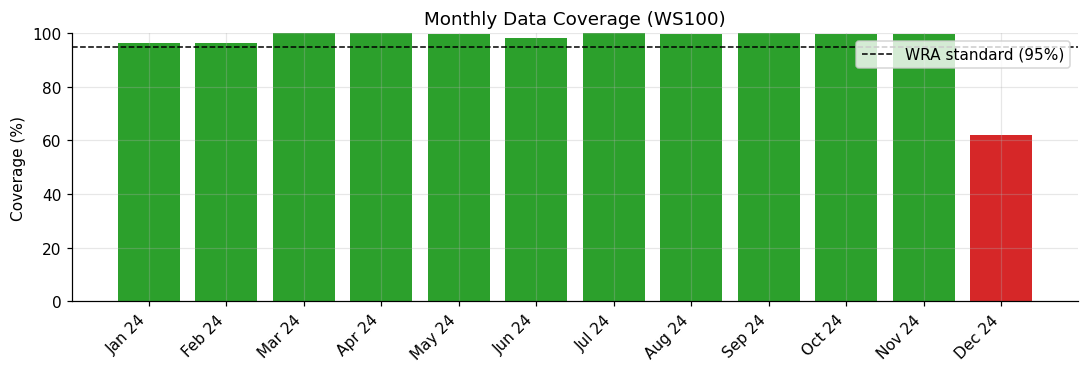

In [7]:
# run_qc: เอาไว้กรองค่าผิดปกติของเซนเซอร์ + คำนวณ TI
clean = qc.run_qc(raw_data)
print(clean["Temp"].min(), clean["Temp"].max())
print(clean["Pres"].min(), clean["Pres"].max())
display(qc.coverage_report(clean)) # coverage % รายเซนเซอร์ + ผ่านหรือไม่ผ่านเกณฑ์ 95%

for sensor_stuck in [TOP, BASE]:
    sensor_before = raw_data[sensor_stuck].notna().mean() * 100
    sensor_after = clean[sensor_stuck].notna().mean() * 100
    print(f"{sensor_stuck}: ก่อนทำ QC {sensor_before:.2f}% / หลังจากทำ QC {sensor_after:.2f}% / ข้อมูลที่ตัดออกไป: {sensor_before - sensor_after:.2f}%")

gap = qc.gap_structure(clean[BASE], SITE['records_per_day'])
print(f"ช่องว่างข้อมูลที่ยาวที่สุด : {gap['longest_gap_hours']:.1f} ชม. , ({gap['longest_gap_hours'] / 24:.1f} วัน)")
print(f"ข้อมูลที่ขาดเกิน 1 วัน  : {gap['gaps_over_1day']} ครั้ง") # ยิ่งเยอะ = logger จะดับเป็นก้อนใหญ่

# กราฟ
monthly = clean[BASE].notna().resample('MS').mean() * 100
fig, ax = plt.subplots(figsize = (10, 3.5))
colors = ['#d62728' if v < 80 else '#ff7f0e' if v < 95 else '#2ca02c' for v in monthly]
ax.bar(range(len(monthly)), monthly.values, color = colors)
ax.axhline(95, color = 'k', ls = '--', lw = 1, label = 'WRA standard (95%)')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels([d.strftime('%b %y') for d in monthly.index], rotation = 45, ha = 'right')
ax.set_ylabel('Coverage (%)')
ax.set_ylim(0,100)
ax.set_title(f'Monthly Data Coverage ({BASE})')
ax.legend()
plt.tight_layout()
data_io.save_image(fig, 'monthly_coverage')
plt.show()

### 3.1 Turbulence Intensity (TI)

In [9]:
# TI (ความปั่นป่วน) = SD / ความเร็วเฉลี่ย
# IEC ให้ดูที่ช่วง 15 m/s เป็นหลัก
print('TI ค่ามัธยฐานรวม :', round(clean['TI'].median(), 4))
for lo, hi in [(14,16),(10,12),(6,8)]:
    m = (clean[TOP] >= lo) & (clean[TOP] < hi)
    if m.sum() > 0:
        print(f"ช่วงข้อมูล {lo}-{hi} m/s : TI = {clean.loc[m, 'TI'].mean():.4f} (จาก {m.sum():,} แถว)")
    else:
        print(f"ช่วง {lo}-{hi} m/s : ไม่มีข้อมูล")

TI ค่ามัธยฐานรวม : 0.1088
ช่วงข้อมูล 14-16 m/s : TI = 0.1298 (จาก 10 แถว)
ช่วงข้อมูล 10-12 m/s : TI = 0.0837 (จาก 1,127 แถว)
ช่วงข้อมูล 6-8 m/s : TI = 0.0919 (จาก 8,966 แถว)


### 4.Feature + wind shear (α) + กราฟ Vertical Profile

Win shear (σ) : 0.2241
Row ที่ใช้ได้ : 29,607 จาก 52,704 (56.2%)
Train : 20,725 Row
Test : 8,882 Row
Save: 013054_20260902_081103/vertical_profile.png


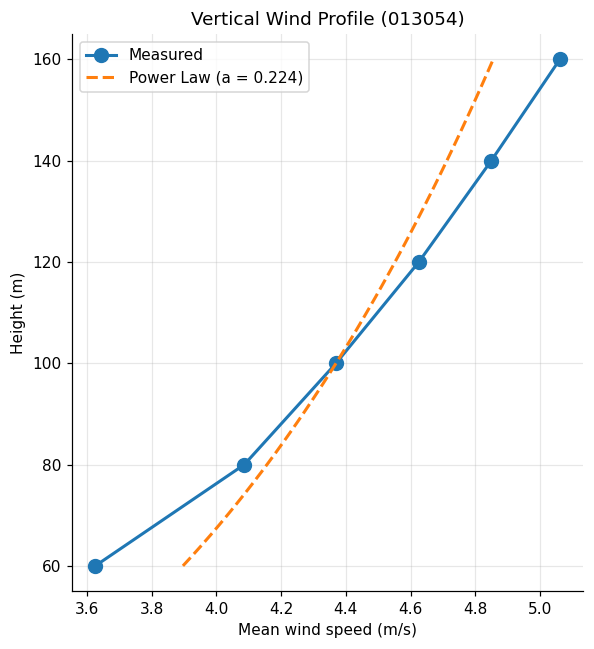

In [10]:
# build_features คือแปลงข้อมูลทิศทางและเวลา เป็นค่า sin-cos + สร้าง shear_low
feat = features.build_features(clean)

# compute_alpha คือการคำนวณค่า Alpha จากข้อมูล และใช้ median
feat, ALPHA = features.compute_alpha(feat)

# splite_by_time แบ่งข้อมูล Train/Test ตามเวลา  
train_data, test_data = features.split_by_time(feat)

num_used = len(train_data) + len(test_data)
print(f"Win shear (σ) : {ALPHA:.4f}")
print(f"Row ที่ใช้ได้ : {num_used:,} จาก {len(feat):,} ({num_used / len(feat) * 100:.1f}%)")
print(f"Train : {len(train_data):,} Row")
print(f"Test : {len(test_data):,} Row")
if num_used / len(feat) < 0.5:
    print('ข้อมูลใช้ได้น้อยกว่าครึ่ง')

# กราฟ Vertical Profile ลมเฉลี่ยและ Power Law
heat_map = {}
for col,h in SITE['sensor_heights'].items():
    if col in clean.columns: heat_map.setdefault(h, []).append(clean[col].mean())

heights = np.array(sorted(heat_map))
mean_wind_speed = np.array([np.mean(heat_map[h]) for h in heights])
fig, ax = plt.subplots(figsize = (5.5, 6))
ax.plot(mean_wind_speed, heights, 'o-', ms = 9, lw = 2, label = 'Measured')

height_level = np.linspace(heights.min(), heights.max(), 50)
ax.plot(mean_wind_speed[heights == BASE_H][0] * (height_level / BASE_H)**ALPHA, height_level, '--', lw = 2, label = f'Power Law (a = {ALPHA:.3f})')
ax.set_xlabel('Mean wind speed (m/s)')
ax.set_ylabel('Height (m)')
ax.set_title(f"Vertical Wind Profile ({SITE['station_code']})")
ax.legend()
plt.tight_layout()
data_io.save_image(fig, 'vertical_profile')
plt.show()

### 5.เทรนโมเดล และวัดผลลัพธ์ที่ได้

In [11]:
# train_all คือเทรน Power Law (baseline) -> Linear -> Random Forest -> RF ที่ผ่าน Alpha แล้ว
# height_lower/height_upper ไม่ต้องส่ง เดี๋ยว train_all อ่านจาก config ของไซต์เอง
scores, trained = models.train_all(train_data, test_data, FEATURES, TARGET, ALPHA)
print(f'Power Law baseline : {BASE_H} ม. -> {SITE["mast_height_m"]} ม.')
display(scores)

Power Law baseline : 100 ม. -> 160 ม.


,MAE,RMSE,MAPE,R2
model,,,,
HistgradientBoosting,0.4559,0.6302,7.8655,0.9207
QGB pass α,0.4493,0.6333,7.9388,0.9199
Random Forest,0.4640,0.6425,7.8629,0.9176
LightGBM,0.4685,0.6454,8.1356,0.9169
Random Forest pass α,0.4685,0.6496,7.8396,0.9158
Linear Regression,0.4760,0.6523,8.0356,0.9151
Quantile GB (median),0.4699,0.6543,8.1454,0.9145
XGBoost,0.4992,0.6865,8.7651,0.9059
MLP pass α,0.5574,0.7559,8.9021,0.8859


In [12]:
# เช็ค key/label
print('keys ในโมเดล :', list(trained.keys()))
print('labels ในตาราง :', scores.index.tolist())

keys ในโมเดล : ['linear', 'random_forest', 'hist_gb', 'svr', 'mlp', 'qgb', 'xgboost', 'lightgbm', 'random_forest_alpha', 'mlp_alpha', 'qgb_alpha']
labels ในตาราง : ['HistgradientBoosting', 'QGB pass α', 'Random Forest', 'LightGBM', 'Random Forest pass α', 'Linear Regression', 'Quantile GB (median)', 'XGBoost', 'MLP pass α', 'MLP', 'SVR', 'Power Law (baseline)']


In [13]:
# save Model
models.save_model(
    trained['random_forest_alpha'], 
    'random_forest_alpha', 
    DATA_VERSION, 
    FEATURES, 
    scores.loc['Random Forest pass α'].to_dict(),
    )

models.save_model(
    trained['mlp'], 
    'mlp_ws160', 
    DATA_VERSION, 
    FEATURES, 
    scores.loc['MLP'].to_dict(),
    )

models.save_model(
    trained['qgb'], 
    'qgb_p50_ws160', 
    DATA_VERSION, 
    FEATURES, 
    scores.loc['Quantile GB (median)'].to_dict(),
    )

'qgb_p50_ws160_013054_02092026_0811_8a2429e9'

#### 5.1 กราฟเทียบ RMSE ของทุกโมเดล

Save: 013054_20260902_081103/model_comparison.png


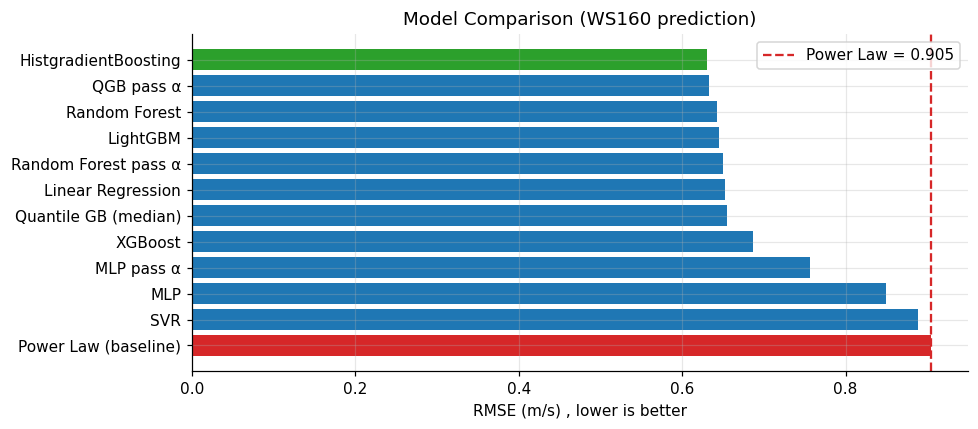

Model ที่ดีที่สุด: HistgradientBoosting  (RMSE = 0.6302, R2 = 0.9207)


In [14]:
order = scores.sort_values('RMSE', ascending=True)
colors = ['#d62728' if m == 'Power Law (baseline)' else '#2ca02c' if i == 0 else '#1f77b4'
          for i, m in enumerate(order.index)]
fig, ax = plt.subplots(figsize = (9,4))
ax.barh(range(len(order)), order['RMSE'].values, color = colors)
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order.index)
ax.invert_yaxis() # โมเดลที่ดีที่สุดอยู่ข้างบน

base = scores.loc['Power Law (baseline)','RMSE']
ax.axvline(base, color='#d62728', ls = '--', lw = 1.5, label = f'Power Law = {base:.3f}')
ax.set_xlabel('RMSE (m/s) , lower is better'); ax.set_title(f'Model Comparison ({TARGET} prediction)')
ax.legend()
plt.tight_layout()
data_io.save_image(fig, 'model_comparison')
plt.show()

best = order.index[0]
print(f'Model ที่ดีที่สุด: {best}  (RMSE = {order.iloc[0]["RMSE"]:.4f}, R2 = {order.iloc[0]["R2"]:.4f})')

### 6.Hub height + MCP + กราฟ MCP

In [15]:
# HUB_HEIGHT_M มาจาก config ของไซต์ (ตั้งไว้ใน config.py ไม่ต้องแก้ตรงนี้)
kind = 'interpolation' if HUB_HEIGHT_M <= SITE['mast_height_m'] else 'extrapolation'
print(f"hub height = {HUB_HEIGHT_M} ม. , ยอดเสา = {SITE['mast_height_m']} ม. -> {kind}")

hub height = 150 ม. , ยอดเสา = 160 ม. -> interpolation


In [16]:
all_feature = feat[FEATURES].dropna() # เตรียม feature สำหรับโมเดล
model_prediction_hub_height = {}

# ประเภทของโมเดล
# direct = เอาไว้ใช้ทำนายลม
# alpha = เอาไว้ทำนายค่า alpha แล้วใช้ Power Law
model_modes = {
    # direct
    "linear": "direct",
    "random_forest": "direct",
    "hist_gb": "direct",
    "svr": "direct",
    "xgboost": "direct",
    "lightgbm": "direct",
    "mlp": "direct",
    "qgb": "direct",

    # alpha
    "random_forest_alpha": "alpha",
    "mlp_alpha": "alpha",
    "qgb_alpha": "alpha",
}

for model_key, mode in model_modes.items():
    if model_key not in trained:
        continue

    model_prediction_hub_height[model_key] = models.predict_hub_wind(
        model = trained[model_key],
        features = all_feature,
        mode = mode,
        base_col = BASE,
        height_lower = BASE_H,
        height_upper = HUB_HEIGHT_M,
    )

# รวมผลลัพธ์ของทุกโมเดล
sum_model_wind_hub = pd.DataFrame(
    model_prediction_hub_height,
    index = all_feature.index
)
display(sum_model_wind_hub.head())

,linear,random_forest,hist_gb,svr,xgboost,lightgbm,mlp,qgb,random_forest_alpha,mlp_alpha,qgb_alpha
timestamp,,,,,,,,,,,
2024-01-01 00:00:00,3.858888,4.176142,4.014611,4.227782,4.050910,4.047578,4.510332,3.944646,3.846796,4.051014,3.731261
2024-01-01 00:10:00,3.474227,4.506803,4.269885,4.355516,4.452721,4.397978,4.232211,4.259977,4.023724,3.903917,4.046116
2024-01-01 00:20:00,3.405503,4.665249,4.234510,4.442404,4.576180,4.486464,4.115014,4.438279,3.999925,3.921702,3.941691
2024-01-01 00:30:00,4.806614,4.857109,4.886396,5.005405,4.868088,5.058585,5.094180,4.701088,4.787318,5.046018,4.616274
2024-01-01 00:40:00,4.168427,4.777820,4.837299,4.902548,4.739627,4.758839,4.747869,4.503083,4.410849,4.533948,4.236649


#### เลือกโมเดลที่จะนำไปทำ MCP

In [17]:
# ฟังก์ชันสร้าง feature สำหรับ MCP
def mcp_features(day):
    day = day.copy()
    day['month_sin'] = np.sin(2 * np.pi * day.index.dayofyear / 365)
    day['month_cos'] = np.cos(2 * np.pi * day.index.dayofyear / 365)
    day['hour_sin'] = np.sin(2 * np.pi * day.index.hour / 24)
    day['hour_cos'] = np.cos(2 * np.pi * day.index.hour / 24)
    return day

MCP_COLS = ['era_ws','month_sin','month_cos','hour_sin','hour_cos']
mcp_models = {}
mcp_score_list = {}
mcp_overlaps = {}

for model_key in sum_model_wind_hub.columns:
    model_wind_hub = sum_model_wind_hub[model_key].dropna()

    overlap_model = mcp_features(era5_data.join(model_wind_hub.resample("1h").mean().rename("site"), how = "inner").dropna())

    # ถ้าข้อมูลไม่พอ ให้ข้ามโมเดลนั้น
    if len(overlap_model) < 20:
        continue
    cut_model = overlap_model.index[int(len(overlap_model) * 0.7)]

    # MCP
    mcp_model = models.make_random_forest(min_samples_leaf = 10).fit(
        overlap_model.loc[:cut_model, MCP_COLS],
        overlap_model.loc[:cut_model, "site"]
        )

    score_model = models.evaluate(
        overlap_model.loc[cut_model:, "site"],
        mcp_model.predict(overlap_model.loc[cut_model:, MCP_COLS]),f"MCP using {model_key}")

    mcp_models[model_key] = mcp_model
    mcp_score_list[model_key] = {k: v for k, v in score_model.items() if k != "model"}
    mcp_overlaps[model_key] = (overlap_model, cut_model)

# ตารางเปรียบเทียบ MCP ของทุกโมเดล
mcp_scores = pd.DataFrame(mcp_score_list).T.sort_values("RMSE")
display(mcp_scores)

,MAE,RMSE,MAPE,R2
svr,1.764846,2.142596,34.435680,-0.803329
random_forest,2.169643,2.559274,48.273254,-1.149085
qgb,2.211493,2.599648,49.914791,-1.069374
xgboost,2.211649,2.632014,49.159359,-1.133940
hist_gb,2.232588,2.648702,50.126536,-1.109896
lightgbm,2.247966,2.656452,50.596291,-1.114135
mlp,2.427998,2.941986,47.749839,-0.971703
mlp_alpha,2.445454,3.015655,42.168198,-0.984807
qgb_alpha,2.528810,3.081283,43.566089,-0.911807
random_forest_alpha,2.556528,3.115542,45.491515,-1.059485


#### เลือกโมเดลที่มี RMSE ต่ำสุดอัตโนมัติ

In [18]:
BEST_MODEL = mcp_scores["RMSE"].idxmin()

wind_hub = sum_model_wind_hub[BEST_MODEL].dropna()
mcp = mcp_models[BEST_MODEL]
overlap, cut = mcp_overlaps[BEST_MODEL]
best_r2 = mcp_scores.loc[BEST_MODEL, 'R2']
print(f"Model ที่เลือกไปทำ MCP: {BEST_MODEL} (RMSE = {mcp_scores.loc[BEST_MODEL, 'RMSE']:.4f}, R2 = {best_r2:.4f})")

Model ที่เลือกไปทำ MCP: svr (RMSE = 2.1426, R2 = -0.8033)


In [19]:
# ทำนายลมย้อนหลัง 20 ปี
longterm = mcp_features(era5_data)
longterm['wind_lt'] = mcp.predict(longterm[MCP_COLS])

annual = era5_data['era_ws'].resample('YS').mean()
annual = annual[era5_data['era_ws'].resample('YS').size() > 8000]
IAV = float(annual.std() / annual.mean())
diff = (wind_hub.mean() / longterm['wind_lt'].mean() - 1) * 100

print(f"IAV (ความผันผวนรายปี) : {IAV * 100:.2f}%")
print(f"ปีที่ทำการวัด เปรียบเทียบกับ ค่าระยะยาว : {diff:+.2f}%")
if abs(diff) > 3 * IAV * 100 and best_r2 < 0.6:
    print(f"ผลต่าง {diff:+.1f}% สูงกว่าค่า IAV แต่ค่า MCP R2 = {best_r2:.2f} ต่ำ")

IAV (ความผันผวนรายปี) : 4.00%
ปีที่ทำการวัด เปรียบเทียบกับ ค่าระยะยาว : -5.37%


Save: 013054_20260902_081103/mcp_fit_longterm.png


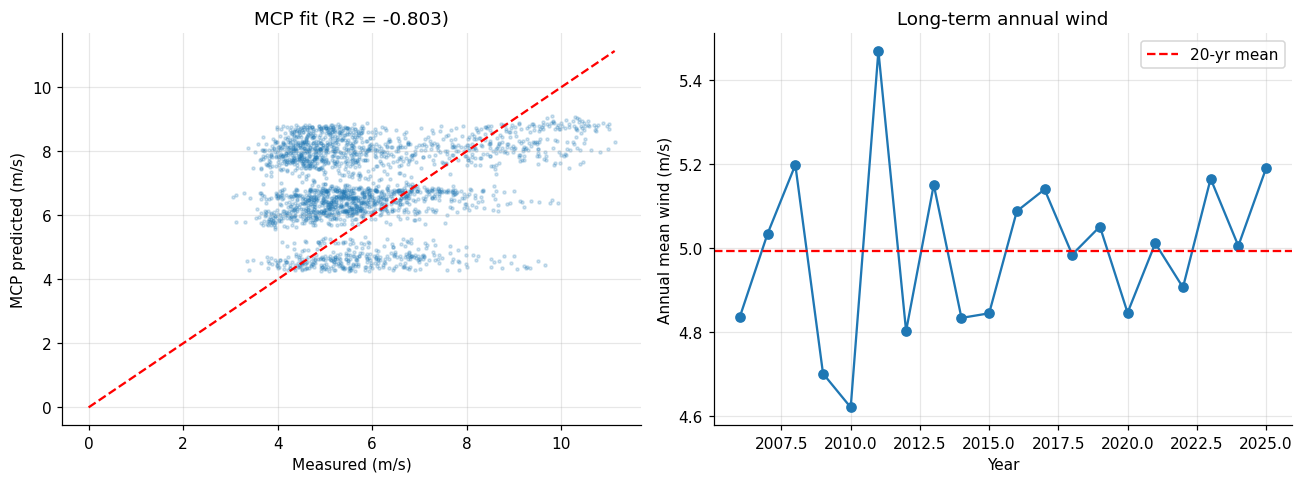

In [20]:
# กราฟ MCP
overview_longterm = overlap.loc[cut:]
fig, ax = plt.subplots(1, 2, figsize = (12, 4.5))
ax[0].scatter(overview_longterm['site'], mcp.predict(overview_longterm[MCP_COLS]), s = 4, alpha = 0.2)
limit = [0, max(overview_longterm['site'].max(), 1)]
ax[0].plot(limit, limit, 'r--')

ax[0].set_xlabel('Measured (m/s)');
ax[0].set_ylabel('MCP predicted (m/s)')
ax[0].set_title(f"MCP fit (R2 = {best_r2:.3f})")

ax[1].plot(annual.index.year, annual.values, 'o-')
ax[1].axhline(annual.mean(), color = 'r', ls = '--', label = f'{len(annual)}-yr mean')

ax[1].set_xlabel('Year')
ax[1].set_ylabel('Annual mean wind (m/s)')
ax[1].set_title('Long-term annual wind')
ax[1].legend()
plt.tight_layout()
data_io.save_image(fig, 'mcp_fit_longterm')
plt.show()

### 7.Weibull -> AEP -> P50/P90 และแสดงกราฟ Weibull และ Exceedance

Weibull k = 4.484, A = 6.366 m/s (mean = 5.808 m/s)
Air density (rho) = 1.1521 kg/m3
Capacity Factor = 10.04%
Total sigma = 9.34%
Save: 013054_20260902_081103/weibull_exceedance.png


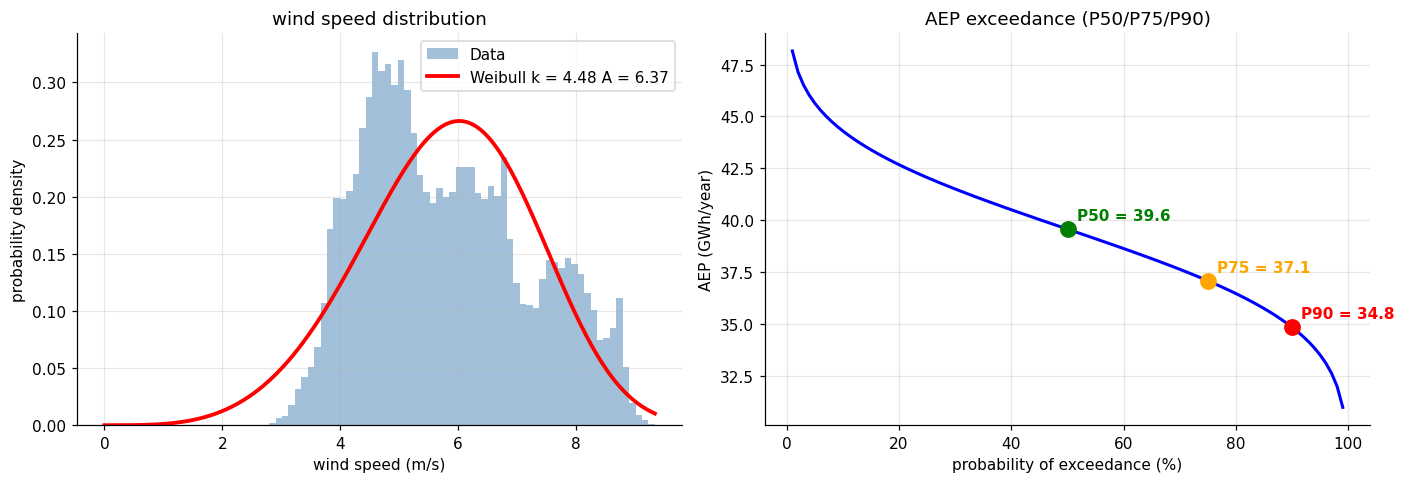

In [21]:
from scipy import stats
# fit Weibull จากค่าลมระยะยาว 20 ปี
k, A = energy.fit_weibull(longterm['wind_lt'])
adc = energy.air_density(clean['Temp'].median(), clean['Pres'].median())
aep = energy.calculate_aep(k, A, adc)

UNCERTAINTY = {'measurement':.03, 'vertical':.04, 'mcp':.035, 'power_curve':.05, 'wake':.03, 'iav':IAV} # ค่าจำลอง
p = energy.exceedance_levels(aep['net_farm_gwh'], UNCERTAINTY)

print(f"Weibull k = {k:.3f}, A = {A:.3f} m/s (mean = {energy.weibull_mean(k,A):.3f} m/s)")
print(f"Air density (rho) = {adc:.4f} kg/m3")
print(f"Capacity Factor = {aep['capacity_factor_pct']:.2f}%")
print(f"Total sigma = {p['sigma_total'] * 100:.2f}%")

# กราฟซ้าย Weibull-fit ,กราฟขวา Execcdance P50/P75/P90
fig, ax = plt.subplots(1, 2, figsize = (13, 4.5))
value = longterm['wind_lt'].dropna().to_numpy()
value = value[value > 0]
ax[0].hist(value, bins = 60, density = True, alpha = .5, color = 'steelblue', label = 'Data')

excluding_Short_term = np.linspace(0, value.max(), 200)
ax[0].plot(excluding_Short_term, stats.weibull_min.pdf(excluding_Short_term, k, 0, A), 'r-', lw = 2.5, label = f'Weibull k = {k:.2f} A = {A:.2f}')
ax[0].set_xlabel('wind speed (m/s)')
ax[0].set_ylabel('probability density')
ax[0].set_title('wind speed distribution')
ax[0].legend()

probs = np.linspace(1, 99, 99)
ax[1].plot(probs, p['P50'] * (1 - stats.norm.ppf(probs / 100) * p['sigma_total']), 'b-', lw = 2)
for lab, pr, c in [('P50', 50, 'green'), ('P75', 75, 'orange'), ('P90', 90, 'red')]:
    val = p['P50'] * (1 - stats.norm.ppf(pr / 100) * p['sigma_total'])
    ax[1].plot(pr, val, 'o', color = c, ms = 10)
    ax[1].annotate(f'{lab} = {val:.1f}', (pr, val), textcoords = 'offset points', xytext = (6, 6), color = c, fontweight = 'bold')

ax[1].set_xlabel('probability of exceedance (%)')
ax[1].set_ylabel('AEP (GWh/year)')
ax[1].set_title('AEP exceedance (P50/P75/P90)')
plt.tight_layout()
data_io.save_image(fig, 'weibull_exceedance')
plt.show()

#### 7.1 Probability Distribution ของ AEP (เทียบ P50 / P75 / P90)
ยิ่งความไม่แน่นอน (sigma) สูง เส้นโค้งยิ่งกว้าง ระยะห่างระหว่าง P50 กับ P90 ยิ่งถ่างออก
ธนาคารดูที่ P90 เพราะเป็นค่าที่มีโอกาสทำได้จริงถึง 90%

,Exceedance (%),AEP (GWh/year),z-score,vs P50 (%)
Level,,,,
P50,50.0,39.56,0.000,0.00
P75,75.0,37.07,0.674,-6.30
P90,90.0,34.83,1.282,-11.97


Save: 013054_20260902_081103/aep_probability_distribution.png


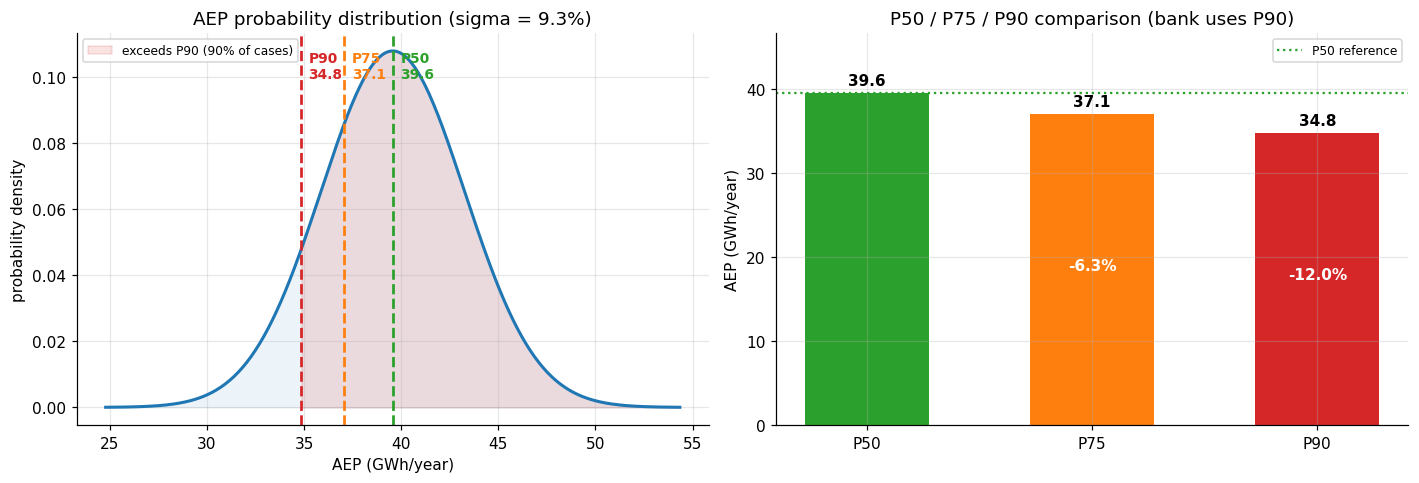

In [22]:
# ตารางเทียบ P50/P75/P90 (ค่า z และส่วนต่างจาก P50)
pxx_table = energy.exceedance_table(p['P50'], p['sigma_total'])
display(pxx_table)

# AEP ถือว่าแจกแจงแบบ Normal รอบ P50 ด้วยส่วนเบี่ยงเบน = P50 * sigma_total
dist = energy.aep_distribution(p['P50'], p['sigma_total'])
level_color = {'P50': '#2ca02c', 'P75': '#ff7f0e', 'P90': '#d62728'}
aep_col = 'AEP (GWh/year)'

fig, ax = plt.subplots(1, 2, figsize = (13, 4.5))

# กราฟซ้าย: Probability Distribution ของ AEP พร้อมเส้น P50/P75/P90
ax[0].plot(dist['x'], dist['pdf'], color = '#1f77b4', lw = 2)
ax[0].fill_between(dist['x'], dist['pdf'], color = '#1f77b4', alpha = 0.08)

# แรเงาช่วงที่ทำได้เกิน P90 พื้นที่ตรงนี้ = 90% ของการแจกแจง
p90 = pxx_table.loc['P90', aep_col]
over_p90 = dist['x'] >= p90
ax[0].fill_between(dist['x'][over_p90], dist['pdf'][over_p90], color = '#d62728', alpha = 0.13, label = 'exceeds P90 (90% of cases)')

top_pdf = dist['pdf'].max()
for level, color in level_color.items():
    value = pxx_table.loc[level, aep_col]
    ax[0].axvline(value, color = color, ls = '--', lw = 1.8)
    ax[0].annotate(f'{level}\n{value:.1f}', (value, top_pdf), textcoords = 'offset points',
                   xytext = (5, -18), color = color, fontweight = 'bold', fontsize = 9)

ax[0].set_xlabel('AEP (GWh/year)')
ax[0].set_ylabel('probability density')
ax[0].set_title(f"AEP probability distribution (sigma = {dist['sigma_total'] * 100:.1f}%)")
ax[0].legend(loc = 'upper left', fontsize = 8)

# กราฟขวา: เทียบค่าแต่ละระดับเป็นแท่ง
bars = ax[1].bar(pxx_table.index, pxx_table[aep_col], width = 0.55,
                 color = [level_color[i] for i in pxx_table.index])
ax[1].bar_label(bars, fmt = '%.1f', padding = 3, fontweight = 'bold')
ax[1].axhline(p['P50'], color = '#2ca02c', ls = ':', lw = 1.5, label = 'P50 reference')

for i, (level, row) in enumerate(pxx_table.iterrows()):
    if level != 'P50':
        ax[1].annotate(f"{row['vs P50 (%)']:+.1f}%", (i, row[aep_col] / 2), ha = 'center',
                       color = 'white', fontweight = 'bold', fontsize = 10)

ax[1].set_ylabel('AEP (GWh/year)')
ax[1].set_ylim(0, pxx_table[aep_col].max() * 1.18)
ax[1].set_title('P50 / P75 / P90 comparison (bank uses P90)')
ax[1].legend(fontsize = 8)

plt.tight_layout()
data_io.save_image(fig, 'aep_probability_distribution')
plt.show()

### 8.ตารางความคุ้มค่าการลงทุน

In [23]:
# อธิบายความหมาย
print('P50/P75/P90 = ระดับค่าความน่าจะเป็น ความเชื่อมั่นในทางสถิติ')
print('NPV = กำไรสุทธิ ค่าบวกถือว่าคุ้มทุน')
print('IRR = ผลตอบแทน %')
print('LCOE = ต้นทุนต่อหน่วย ค่าต่ำถือว่าดี')

capacity_mw = energy.DEFAULT_TURBINE['rated_kw'] * energy.DEFAULT_TURBINE['num_turbines'] / 1000
rows = []
for lab in ['P50', 'P75', 'P90']:
    r = finance.financial_analysis(p[lab], capacity_mw)
    rows.append({
        'Level':lab, 'AEP (GWh)':round(p[lab],2),
        'NPV (MTHB)':round(r['NPV_mthb'],2),
        'IRR (%)':round(r['IRR_pct'],2),
        'Break even (year)':r['payback_years'],
        'LCOE (THB/kWh)':round(r['LCOE_thb_per_kwh'],2)
        })
finance_table = pd.DataFrame(rows).set_index('Level')

# ต่อคอลัมน์จากตาราง exceedance เข้าไป จะได้เห็น z-score กับส่วนต่างจาก P50 ในตารางเดียว
finance_table = pxx_table[['Exceedance (%)', 'z-score', 'vs P50 (%)']].join(finance_table)
display(finance_table)

P50/P75/P90 = ระดับค่าความน่าจะเป็น ความเชื่อมั่นในทางสถิติ
NPV = กำไรสุทธิ ค่าบวกถือว่าคุ้มทุน
IRR = ผลตอบแทน %
LCOE = ต้นทุนต่อหน่วย ค่าต่ำถือว่าดี


,Exceedance (%),z-score,vs P50 (%),AEP (GWh),NPV (MTHB),IRR (%),Break even (year),LCOE (THB/kWh)
Level,,,,,,,,
P50,50.0,0.000,0.00,39.56,-1606.58,-7.62,None,7.28
P75,75.0,0.674,-6.30,37.07,-1677.47,-9.01,None,7.77
P90,90.0,1.282,-11.97,34.83,-1741.28,-10.50,None,8.27


#### 8.1 บันทึกผลเป็นไฟล์ .csv ลง Folder data/outputs/

In [24]:
# บันทึกผลเป็น .csv ทุกไฟล์ลงโฟลเดอร์ของรอบนี้ data/outputs/<RUN_ID>/
data_io.save_output(scores, 'model_scores') # ตารางเปรียบเทียบโมเดล
data_io.save_output(pxx_table, 'exceedance_PXX') # ตาราง P50/P75/P90
data_io.save_output(finance_table, 'finance_PXX') # ตารางความคุ้มทุน
data_io.save_output(longterm[['wind_lt']], 'longterm_wind') # ลมระยะยาว 20 ปี

summary = pd.DataFrame([{ #TODO ซ้ำ
    'site': SITE['station_code'],
    'data_version': DATA_VERSION,
    'alpha': round(ALPHA,4),
    'weibull_k': round(k,3),
    'weibull_A': round(A,3),
    'capacity_factor_pct': round(aep['capacity_factor_pct'],2),
    'hub_height_m': HUB_HEIGHT_M,
    'sigma_total_pct': round(p['sigma_total'] * 100, 2),
    'P50_GWh': round(p['P50'],2),
    'P75_GWh': round(p['P75'],2),
    'P90_GWh': round(p['P90'],2),
    'NPV_P90_MTHB': round(finance.financial_analysis(p['P90'], capacity_mw)['NPV_mthb'],1),
}])
data_io.save_output(summary, 'site_summary')
display(summary.T)

print('')
print('ไฟล์อยู่ที่ :', data_io.run_dir())
display(data_io.list_runs())

Save: 013054_20260902_081103/model_scores.csv
Save: 013054_20260902_081103/exceedance_PXX.csv
Save: 013054_20260902_081103/finance_PXX.csv
Save: 013054_20260902_081103/longterm_wind.csv
Save: 013054_20260902_081103/site_summary.csv


,0
site,013054
data_version,013054_02092026_0811_8a2429e9
alpha,0.2241
weibull_k,4.484
weibull_A,6.366
capacity_factor_pct,10.04
hub_height_m,150
sigma_total_pct,9.34
P50_GWh,39.56
P75_GWh,37.07



ไฟล์อยู่ที่ : /home/jovyan/project/data/outputs/013054_20260902_081103


,run_id,site,created,data_version,num_files,note
0,GWD_10_160_20260814_075413,GWD_10_160,2026-08-14T07:54:13,GWD_10_160_14082026_0754_5e4ed290,11,ข้อมูลจำลอง
1,GWD_10_160_20260814_074425,GWD_10_160,2026-08-14T07:44:25,GWD_10_160_14082026_0744_5e4ed290,11,ข้อมูลจำลอง
2,GWD_10_160_20260814_071103,GWD_10_160,2026-08-14T07:11:03,GWD_10_160_14082026_0711_5e4ed290,0,ข้อมูลจำลอง
3,GWD_10_160_20260813_100144,GWD_10_160,2026-08-13T10:01:44,GWD_10_160_13082026_1001_5e4ed290,11,ข้อมูลจำลอง
4,GWD_10_160_20260813_094914,GWD_10_160,2026-08-13T09:49:14,GWD_10_160_13082026_0949_5e4ed290,6,ข้อมูลจำลอง
5,GWD_10_160_20260813_081447,GWD_10_160,2026-08-13T08:14:47,GWD_10_160_20260813_0814_5e4ed290,11,ข้อมูลจำลอง
6,GWD_10_160_20260811_104144,GWD_10_160,2026-08-11T10:41:44,GWD_10_160_2026 08 11_ 10 41_5e4ed290,11,ข้อมูลจำลอง
7,013054_20260902_081103,013054,2026-09-02T08:11:03,013054_02092026_0811_8a2429e9,11,ERA5 + RawData_2024
8,013054_20260902_073904,013054,2026-09-02T07:39:04,013054_02092026_0739_8a2429e9,8,ไม่ทำ MCP - ใช้ลมวัดจริง 1 ปี + IAV
9,013054_20260828_101627,013054,2026-08-28T10:16:27,013054_28082026_1016_8a2429e9,7,ไม่ทำ MCP - ใช้ลมวัดจริง 1 ปี + IAV


### 9.สรุปผลที่ได้

In [25]:
from datetime import datetime
res90 = finance.financial_analysis(p['P90'], capacity_mw)
irr_text = f"{res90['IRR_pct']:.2f}%" if pd.notna(res90['IRR_pct']) else "nan"

print(f"ไซต์งาน: {SITE['station_code']}")
print(f"จังหวัด: {SITE['province']}")
print(f"Latitude / Longitude: ({SITE['latitude']}, {SITE['longitude']})")
print('')
print(f"ช่วงข้อมูล: {raw_data.index.min():%d %b %Y} - {raw_data.index.max():%d %b %Y}")
print(f"Data version: {DATA_VERSION} .ช่วง {datetime.now():%d %b %Y %H:%M}")
print('')
print(f"Alpha (α) = {ALPHA:.4f}")
print(f"Weibull k = {k:.3f}, A = {A:.3f}")
print(f"Capacity Factor = {aep['capacity_factor_pct']:.2f}%")
print(f"ความไม่แน่นอน (sigma) = {p['sigma_total'] * 100:.2f}%")
print(f"P50 = {p['P50']:.2f} GWh/ปี")
print(f"P75 = {p['P75']:.2f} GWh/ปี ({p['P75'] / p['P50'] * 100 - 100:+.1f}% จาก P50)")
print(f"P90 = {p['P90']:.2f} GWh/ปี ({p['P90'] / p['P50'] * 100 - 100:+.1f}% จาก P50)")
print('')
print(f"ข้อสรุป (P90): {'คุ้มค่า' if res90['NPV_mthb'] > 0 else 'ยังไม่คุ้มค่า'}")
print(f"NPV = {res90['NPV_mthb']:.2f} ล้านบาท")
print(f"IRR = {irr_text}")
print(f"LCOE = {res90['LCOE_thb_per_kwh']:.2f} บาท/kWh")
print('')
print(f"ผลลัพธ์: {RUN_ID}")

ไซต์งาน: 013054
จังหวัด: ยโสธร
Latitude / Longitude: (15.98565, 104.2271899)

ช่วงข้อมูล: 01 Jan 2024 - 31 Dec 2024
Data version: 013054_02092026_0811_8a2429e9 .ช่วง 02 Sep 2026 08:13

Alpha (α) = 0.2241
Weibull k = 4.484, A = 6.366
Capacity Factor = 10.04%
ความไม่แน่นอน (sigma) = 9.34%
P50 = 39.56 GWh/ปี
P75 = 37.07 GWh/ปี (-6.3% จาก P50)
P90 = 34.83 GWh/ปี (-12.0% จาก P50)

ข้อสรุป (P90): ยังไม่คุ้มค่า
NPV = -1741.28 ล้านบาท
IRR = -10.50%
LCOE = 8.27 บาท/kWh

ผลลัพธ์: 013054_20260902_081103
